# 07 — ML Strategy Learner

Can a machine-learned strategy beat the hand-tuned rules from notebook 06,
given the exact same information? This notebook trains
`quantlab.strategies.MLTradingStrategy` — a bag of **from-scratch random
regression trees** (`quantlab.learners`, numpy only, no sklearn) — to
predict 5-day forward returns from the notebook-04 indicators, and trades
only when the predicted move clears the cost hurdle.

The evaluation protocol is strict:

- **Train:** 2016–2019. **Test:** 2020–2023, never touched during training.
- Same symbol (MSFT), position limits, commission and impact as notebook 06.
- The label uses future returns, so labels are only ever computed on the
  training window; features use trailing windows only.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quantlab.backtest import affordable_shares, positions_to_trades, run_backtest, summarize
from quantlab.backtest.engine import buy_and_hold_benchmark
from quantlab.data import load_prices
from quantlab.strategies import ManualRuleStrategy, MLTradingStrategy

plt.rcParams["figure.figsize"] = (11, 5)

SYMBOL = "MSFT"
TRAIN = slice("2016-01-01", "2019-12-31")
TEST = slice("2020-01-01", "2023-12-31")
START_CASH = 100_000
COMMISSION = 1.00
IMPACT = 0.001

prices = load_prices(SYMBOL, "2016-01-01", "2023-12-31")[SYMBOL]
train_prices, test_prices = prices.loc[TRAIN], prices.loc[TEST]


def backtest_positions(positions: pd.Series, window_prices: pd.Series, name: str):
    max_shares = affordable_shares(window_prices, START_CASH)
    trades = positions_to_trades(positions, max_shares=max_shares)
    values = run_backtest(
        trades, window_prices, start_cash=START_CASH, commission=COMMISSION, impact=IMPACT
    )["value"]
    return values, summarize(values, name)


def benchmark(window_prices: pd.Series) -> pd.Series:
    shares = affordable_shares(window_prices, START_CASH)
    return buy_and_hold_benchmark(
        window_prices, START_CASH, shares, COMMISSION, IMPACT
    )["value"]

## Why from-scratch bagged random trees?

A single decision tree on noisy financial targets overfits catastrophically;
bagging many *random-split* trees trades a little bias for a large variance
reduction. The learners live in
[`quantlab/learners/`](../src/quantlab/learners/) with unit tests showing
the bag beats any single random tree out-of-sample
([`tests/test_learners.py`](../tests/test_learners.py)).

The trade threshold (1% predicted 5-day move) is set above the round-trip
cost of ~0.2% so the model only trades when its edge should survive costs.

In [2]:
ml = MLTradingStrategy(
    n_estimators=25, leaf_size=5, lookahead=5, trade_threshold=0.01, seed=42
)
ml.fit(train_prices)

# Sanity check: in-sample predicted vs realized forward returns
preds_train = ml.predicted_returns(train_prices)
realized_train = (train_prices.shift(-5) / train_prices - 1).reindex(preds_train.index)
both = pd.DataFrame({"predicted": preds_train, "realized": realized_train}).dropna()
print(f"In-sample prediction/realized correlation: {both.corr().iloc[0, 1]:.3f}")

In-sample prediction/realized correlation: 0.806


## In-sample comparison (expect the ML strategy to look great here)

In [3]:
manual = ManualRuleStrategy()
ml_train_vals, ml_train_stats = backtest_positions(
    ml.positions(train_prices), train_prices, "ML learner (in-sample)"
)
manual_train_vals, manual_train_stats = backtest_positions(
    manual.positions(train_prices), train_prices, "manual (in-sample)"
)
bench_train = benchmark(train_prices)
pd.DataFrame(
    [ml_train_stats, manual_train_stats, summarize(bench_train, "buy & hold (in-sample)")]
).round(4)

,cumulative_return,avg_daily_return,daily_volatility,sharpe_ratio,max_drawdown,final_value
ML learner (in-sample),5.5470,0.0019,0.0078,3.8463,-0.0488,654703.6524
manual (in-sample),0.5766,0.0007,0.0225,0.4965,-0.5703,157657.9199
buy & hold (in-sample),2.1223,0.0012,0.0138,1.4118,-0.1823,311917.0480


## Out-of-sample comparison (the one that counts)

In [4]:
ml_test_vals, ml_test_stats = backtest_positions(
    ml.positions(test_prices), test_prices, "ML learner (out-of-sample)"
)
manual_test_vals, manual_test_stats = backtest_positions(
    manual.positions(test_prices), test_prices, "manual (out-of-sample)"
)
bench_test = benchmark(test_prices)
pd.DataFrame(
    [ml_test_stats, manual_test_stats, summarize(bench_test, "buy & hold (out-of-sample)")]
).round(4)

,cumulative_return,avg_daily_return,daily_volatility,sharpe_ratio,max_drawdown,final_value
ML learner (out-of-sample),1.8541,0.0012,0.0190,1.0240,-0.2704,285411.7386
manual (out-of-sample),0.3305,0.0007,0.0290,0.3844,-0.4538,133045.5495
buy & hold (out-of-sample),1.4296,0.0011,0.0205,0.8458,-0.3715,242713.6608


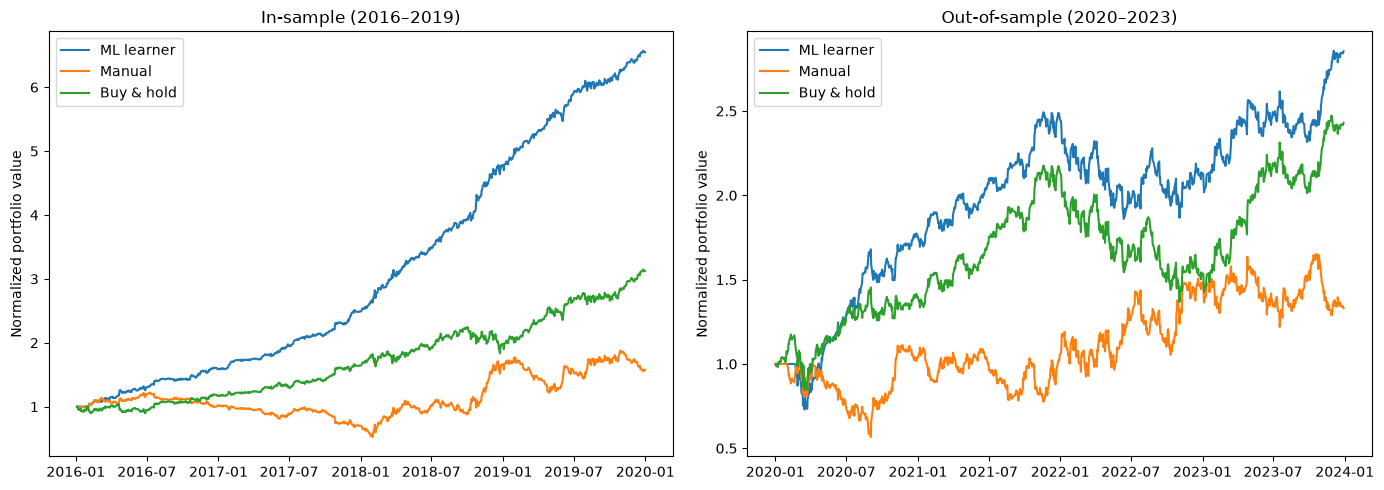

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for values, label in [
    (ml_train_vals, "ML learner"),
    (manual_train_vals, "Manual"),
    (bench_train, "Buy & hold"),
]:
    axes[0].plot(values / values.iloc[0], label=label)
axes[0].set_title("In-sample (2016–2019)")
axes[0].legend()
for values, label in [
    (ml_test_vals, "ML learner"),
    (manual_test_vals, "Manual"),
    (bench_test, "Buy & hold"),
]:
    axes[1].plot(values / values.iloc[0], label=label)
axes[1].set_title("Out-of-sample (2020–2023)")
axes[1].legend()
for ax in axes:
    ax.set_ylabel("Normalized portfolio value")
plt.tight_layout()
plt.savefig("../docs/img/07_ml_vs_manual.png", dpi=120)
plt.show()

## Walk-forward robustness check

One train/test split can mislead. Walk the model forward year by year:
train on a rolling 3-year window, trade the following year, repeat.

In [6]:
walk_prices = load_prices(SYMBOL, "2013-01-01", "2023-12-31")[SYMBOL]
rows = []
for test_year in range(2016, 2024):
    fit_window = walk_prices.loc[f"{test_year - 3}-01-01" : f"{test_year - 1}-12-31"]
    trade_window = walk_prices.loc[f"{test_year}-01-01" : f"{test_year}-12-31"]
    model = MLTradingStrategy(n_estimators=25, leaf_size=5, lookahead=5, trade_threshold=0.01, seed=42)
    model.fit(fit_window)
    values, stats_row = backtest_positions(model.positions(trade_window), trade_window, str(test_year))
    bench = benchmark(trade_window)
    rows.append(
        {
            "year": test_year,
            "ml_return": stats_row["cumulative_return"],
            "buy_hold_return": summarize(bench)["cumulative_return"],
            "ml_sharpe": stats_row["sharpe_ratio"],
        }
    )
walk = pd.DataFrame(rows).set_index("year")
walk.round(4)

,ml_return,buy_hold_return,ml_sharpe
year,,,
2016,0.1585,0.1652,0.8576
2017,0.2430,0.3978,1.5073
2018,0.3955,0.2023,1.3598
2019,0.3987,0.5828,1.7831
2020,0.1688,0.3994,0.5583
2021,0.1211,0.5575,0.6202
2022,-0.1185,-0.2770,-0.2804
2023,-0.0412,0.5837,0.0274


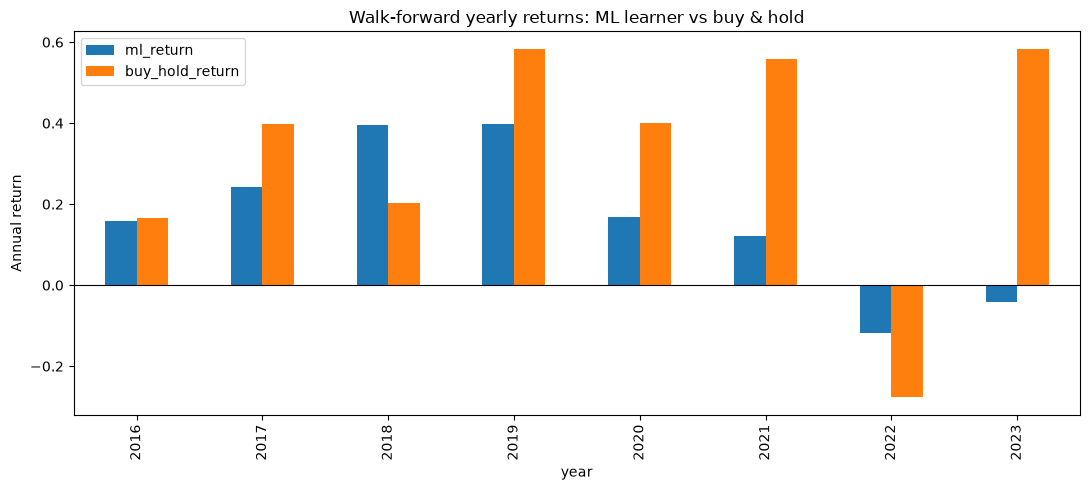

In [7]:
ax = walk[["ml_return", "buy_hold_return"]].plot.bar()
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Walk-forward yearly returns: ML learner vs buy & hold")
ax.set_ylabel("Annual return")
plt.tight_layout()
plt.savefig("../docs/img/07_walk_forward.png", dpi=120)
plt.show()

## Takeaways

- The gap between in-sample and out-of-sample performance is the headline:
  the learner memorizes patterns in its training window that only partially
  persist. Reporting both, on identical cost assumptions, is the core
  discipline of this repo.
- The walk-forward table is the fairest single view — year-by-year, the
  learner's edge over buy-and-hold is inconsistent, exactly what a small IC
  from notebook 04 predicts.
- Everything the learner knows comes from four trailing-window indicators.
  Richer features (cross-sectional fundamentals from notebook 03, the
  outlook factor from notebook 01) are the obvious next step, tracked in
  notebook 09.